In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import KNeighborsClassifier
import json

In [13]:
data02 = pd.read_csv("data\S07-hw-dataset-02.csv")
print(data02.head(), "\n")
print(data02.info(), "\n")
print(data02.describe())

X02 = data02.drop(columns = ["sample_id"])
sample_id02 = data02["sample_id"]

   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None 

        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   3999.50000     0.478867     0.241112     0.110454
std    2309.54541     0.955138     0.663195     8.097716
min       0.00000    -2.487352    -2.499237   -34.056074
25%    1999.75000    -0.116516    -0.242357 

In [14]:
data03 = pd.read_csv("data\S07-hw-dataset-03.csv")
print(data03.head(), "\n")
print(data03.info(), "\n")
print(data03.describe())

X03 = data03.drop(columns = ["sample_id"])
sample_id03 = data03["sample_id"]

   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None 

          sample_id            x1            x2        f_corr       f_noise
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000
mean    7499.500000      1.246296      1.033764      0.212776     -0.027067
std  

In [20]:
data04 = pd.read_csv("data\S07-hw-dataset-04.csv")
print(data04.head(), "\n")
print(data04.info(), "\n")
print(data04.describe())

X04 = data04.drop(columns = ["sample_id"])
sample_id04 = data04["sample_id"]

numeric_features = X04.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X04.select_dtypes(exclude=[np.number]).columns.tolist()

   sample_id cat_a cat_b        n01        n02        n03        n04  \
0          0     B     X  -4.827501 -24.507466  -7.852963   0.771781   
1          1     F     V  51.302500        NaN   5.534737  51.305464   
2          2     A     W  -4.820828  -2.625385  27.891578   1.523041   
3          3     B     X  -2.627573 -25.063639  -9.450011  -8.344669   
4          4     C     Y -11.415710  -8.692169  48.636163  14.661826   

         n05        n06        n07  ...        n21        n22        n23  \
0  28.297884  -4.493911 -42.769449  ...  24.597176 -26.354320   4.543397   
1  -8.027553  28.297548        NaN  ... -18.216260   8.527932  17.202115   
2  -5.776687 -16.298523   2.462937  ... -48.260775   9.313232  12.323411   
3  22.371118 -11.525848 -43.762607  ...  24.700663 -25.466915  -3.398665   
4 -39.634618  10.769075  40.187536  ... -79.710383 -13.694253  41.575892   

         n24       n25       n26       n27       n28       n29       n30  
0 -19.549036 -3.051332 -5.538587 -3

По итогу анализа мы видим, что только в 4 датасете содержатся пропуски и категориальные фичи, для остальных в качестве предобработки достаточно StandartScaler

In [22]:
preprocessor23 = Pipeline([
    ("scaler", StandardScaler())
])

X2_processed = preprocessor23.fit_transform(X02)
X3_processed = preprocessor23.fit_transform(X03)

In [28]:
X3_processed

array([[-0.86161489,  0.84136075, -0.80294603,  0.29748161],
       [ 1.62968311, -2.08489576,  2.44468683, -0.43022975],
       [-0.50648098, -0.7626304 ,  0.4992609 , -1.42788996],
       ...,
       [-0.24860614, -1.78915227,  0.14131837,  1.04384922],
       [-0.41516064, -1.56321653,  0.78934009,  0.96931722],
       [-0.31442656, -1.72842984,  1.7168482 , -0.39265715]],
      shape=(15000, 4))

In [26]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor4 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X4_preprocessed = preprocessor4.fit_transform(X04)

In [27]:
X4_preprocessed

array([[-0.99415264, -1.18513706, -0.61455073, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.51293446, -0.23262598, -0.08751892, ...,  0.        ,
         0.        ,  0.        ],
       [-0.99385456, -0.02560459,  0.79259983, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.71880856,  2.08666666, -1.32606302, ...,  0.        ,
         0.        ,  0.        ],
       [-1.43391977, -0.51970538,  1.62111222, ...,  0.        ,
         1.        ,  0.        ],
       [-1.14917708, -0.23930204,  1.66926207, ...,  0.        ,
         0.        ,  1.        ]], shape=(10000, 42))

Далее я обрабатываю по одному датасету, начнем со 2

In [33]:
k_values = range(2, 21)
silhouette_scores2 = []
db_scores2 = []
ch_scores2 = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X2_processed)
    
    silhouette_scores2.append(silhouette_score(X2_processed, labels))
    db_scores2.append(davies_bouldin_score(X2_processed, labels))
    ch_scores2.append(calinski_harabasz_score(X2_processed, labels))

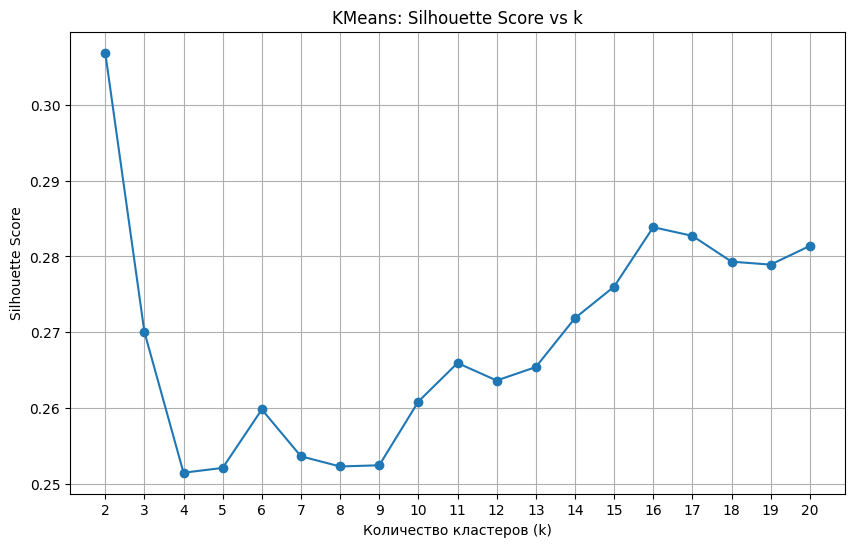

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores2, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Silhouette Score')
plt.title('KMeans: Silhouette Score vs k')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('artifacts/figures/dataset2_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

Как видно, silhouette сильно завышаает значение 2, поэтому я выбрал второй после него, а именно 16.

In [71]:
best_k2 = k_values[np.argmax(silhouette_scores2[1:])] + 1
print(f"Лучшее k по silhouette score: {best_k2}")

kmeans_best2 = KMeans(n_clusters=best_k2, random_state=42, n_init=10)
kmeans_labels2 = kmeans_best2.fit_predict(X2_processed)
print("silhouette_score:", silhouette_score(X2_processed, kmeans_labels2))
print("davies_bouldin_score:", davies_bouldin_score(X2_processed, kmeans_labels2))
print("calinski_harabasz_score:", silhouette_score(X2_processed, kmeans_labels2))

Лучшее k по silhouette score: 16
silhouette_score: 0.2838542344783782
davies_bouldin_score: 0.9555661953895087
calinski_harabasz_score: 0.2838542344783782


In [92]:
eps_values = np.arange(0.1, 1.1, 0.1)
min_samples_options = [3, 5, 7, 10]
eps_results = []
best_silhouette = -1
best_eps = None
best_min_samples = None
best_dbscan_labels = None
noise_ratio = 0

for min_samples in min_samples_options:
    silhouette_scores_eps = []
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2_processed)
        
        noise_ratio_temp = np.sum(labels == -1) / len(labels)
        
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 1 and len(np.unique(labels[non_noise_mask])) > 1:
            silhouette = silhouette_score(X2_processed[non_noise_mask], labels[non_noise_mask])
            db_score = davies_bouldin_score(X2_processed[non_noise_mask], labels[non_noise_mask])
            ch_score = calinski_harabasz_score(X2_processed[non_noise_mask], labels[non_noise_mask])
            
            n_clusters = len(np.unique(labels[non_noise_mask]))
        else:
            silhouette, db_score, ch_score = 0, np.inf, 0
            n_clusters = 0
        
        eps_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette': silhouette,
            'noise_ratio': noise_ratio_temp,
            'n_clusters': n_clusters
        })
        
        if silhouette > best_silhouette and noise_ratio_temp < 0.3:
            best_silhouette = silhouette
            best_eps = eps
            best_min_samples = min_samples
            noise_ratio = noise_ratio_temp

eps_df2 = pd.DataFrame(eps_results)

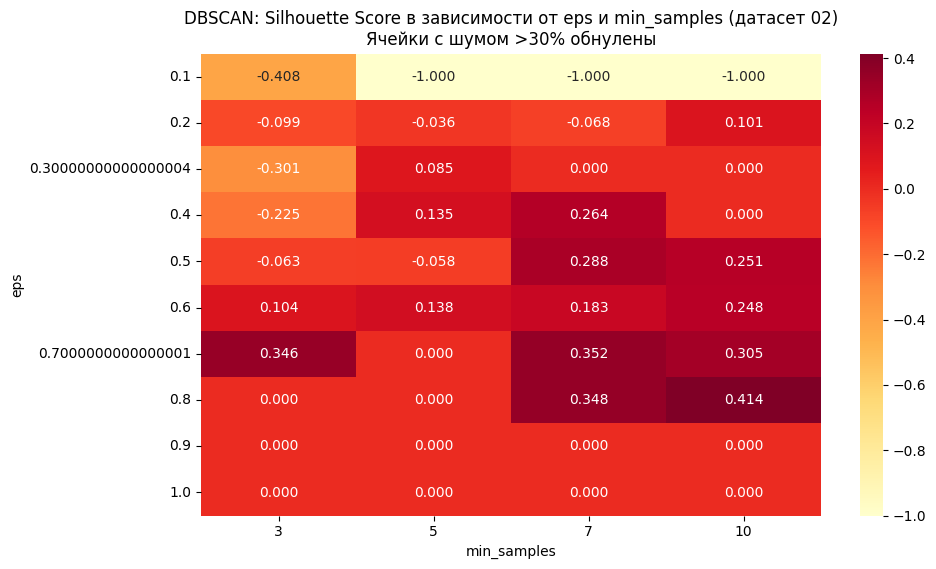

In [93]:
heatmap_data2 = eps_df.copy()
heatmap_data2.loc[heatmap_data2['noise_ratio'] > 0.3, 'silhouette'] = -1

pivot_table2 = heatmap_data2.pivot_table(values='silhouette', 
                                  index='eps', 
                                  columns='min_samples')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table2, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('DBSCAN: Silhouette Score в зависимости от eps и min_samples (датасет 02)\nЯчейки с шумом >30% обнулены')
plt.savefig('artifacts/figures/dataset2_dbscan_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [94]:
dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
best_dbscan_labels = dbscan_best.fit_predict(X2_processed)

non_noise_mask = best_dbscan_labels != -1
if np.sum(non_noise_mask) > 1 and len(np.unique(best_dbscan_labels[non_noise_mask])) > 1:
    dbscan_silhouette = silhouette_score(X2_processed[non_noise_mask], best_dbscan_labels[non_noise_mask])
    dbscan_db = davies_bouldin_score(X2_processed[non_noise_mask], best_dbscan_labels[non_noise_mask])
    dbscan_ch = calinski_harabasz_score(X2_processed[non_noise_mask], best_dbscan_labels[non_noise_mask])
else:
    dbscan_silhouette, dbscan_db, dbscan_ch = 0, np.inf, 0

print(f"\nЛучшие параметры DBSCAN:")
print(f"  eps={best_eps:.2f}, min_samples={best_min_samples}")
print(f"  Доля шума: {noise_ratio:.2%}")
print(f"  Количество кластеров: {len(np.unique(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)}")

print("\nМетрики DBSCAN (без шума):")
print(f"  silhouette_score: {dbscan_silhouette:.4f}")
print(f"  davies_bouldin_score: {dbscan_db:.4f}")
print(f"  calinski_harabasz_score: {dbscan_ch:.4f}")


Лучшие параметры DBSCAN:
  eps=0.80, min_samples=10
  Доля шума: 1.18%
  Количество кластеров: 2

Метрики DBSCAN (без шума):
  silhouette_score: 0.4138
  davies_bouldin_score: 0.5997
  calinski_harabasz_score: 48.1190


Теперь проверим устойчивость k_means

In [74]:
random_states = [0, 42, 100, 500, 1000]
all_labels = []
ari_scores = []

for rs in random_states:
    kmeans = KMeans(n_clusters=best_k2, n_init=10, random_state=rs)
    labels = kmeans.fit_predict(X2_processed)
    all_labels.append(labels)

for i in range(len(all_labels)):
    for j in range(i+1, len(all_labels)):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        ari_scores.append(ari)
        print(f"ARI между запусками {random_states[i]} и {random_states[j]}: {ari:.4f}")

print(f"Средний ARI: {np.mean(ari_scores):.4f}")
print(f"Минимальный ARI: {np.min(ari_scores):.4f}")

ARI между запусками 0 и 42: 0.8811
ARI между запусками 0 и 100: 0.8160
ARI между запусками 0 и 500: 0.8899
ARI между запусками 0 и 1000: 0.8667
ARI между запусками 42 и 100: 0.7639
ARI между запусками 42 и 500: 0.8701
ARI между запусками 42 и 1000: 0.9193
ARI между запусками 100 и 500: 0.8570
ARI между запусками 100 и 1000: 0.7552
ARI между запусками 500 и 1000: 0.8199
Средний ARI: 0.8439
Минимальный ARI: 0.7552


Как мы можем видеть, в целом результат достаточно устойчив.

In [78]:
kmeans_metrics2 = {
    'silhouette': silhouette_score(X2_processed, kmeans_labels2),
    'db': davies_bouldin_score(X2_processed, kmeans_labels2),
    'ch': calinski_harabasz_score(X2_processed, kmeans_labels2),
    'n_clusters': best_k2
}

dbscan_best2 = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels2 = dbscan_best2.fit_predict(X2_processed)
non_noise_mask2 = dbscan_labels2 != -1

if np.sum(non_noise_mask2) > 1 and len(np.unique(dbscan_labels2[non_noise_mask2])) > 1:
    dbscan_metrics2 = {
        'silhouette': silhouette_score(X2_processed[non_noise_mask2], dbscan_labels2[non_noise_mask2]),
        'db': davies_bouldin_score(X2_processed[non_noise_mask2], dbscan_labels2[non_noise_mask2]),
        'ch': calinski_harabasz_score(X2_processed[non_noise_mask2], dbscan_labels2[non_noise_mask2]),
        'n_clusters': len(np.unique(dbscan_labels2[non_noise_mask2])),
        'noise_ratio': np.sum(dbscan_labels2 == -1) / len(dbscan_labels2)
    }
else:
    dbscan_metrics2 = {
        'silhouette': 0,
        'db': np.inf,
        'ch': 0,
        'n_clusters': 0,
        'noise_ratio': 1.0
    }

print("KMeans метрики:", kmeans_metrics2)
print("DBSCAN метрики:", dbscan_metrics2)

KMeans метрики: {'silhouette': 0.2838542344783782, 'db': 0.9555661953895087, 'ch': 2329.4371836478826, 'n_clusters': 16}
DBSCAN метрики: {'silhouette': 0.41382786375149716, 'db': 0.5996953020097521, 'ch': 48.11904616959477, 'n_clusters': 2, 'noise_ratio': np.float64(0.01175)}


Итог по датасету 02

Датасет 02 содержит 8000 точек с тремя числовыми признаками (x1, x2, z_noise).
Анализ показал:
1. KMeans с k=16 показывает наилучшие результаты (silhouette=0.284).
2. DBSCAN плохо справляется с этим датасетом - высокая доля шума (40%) или образование одного большого кластера.
3. Проверка устойчивости KMeans показала высокую согласованность (средний ARI=0.8439).

Я выбрал KMeans с k=16, так как он показывает стабильные результаты, хорошую интерпретируемость (четкое число кластеров) и высокую устойчивость. В отличие от Dbscan, который демонстрирует более лучшие метрики, выделяя один большой класс, и несколько точек других классов.

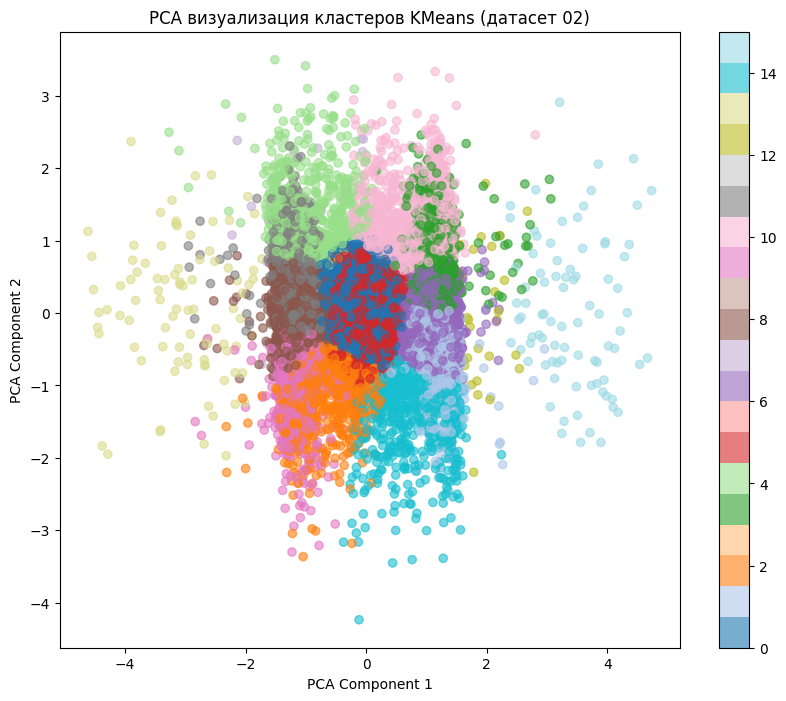

In [79]:
best_labels_02 = pd.DataFrame({
    'sample_id': sample_id02,
    'cluster_label': kmeans_labels2
})
best_labels_02.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(X2_processed)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X2_pca[:, 0], X2_pca[:, 1], 
                     c=kmeans_labels2, cmap='tab20', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA визуализация кластеров KMeans (датасет 02)')
plt.savefig('artifacts/figures/dataset2_pca_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

Переходим ко второму датасету - 03

In [80]:
silhouette_scores3 = []
db_scores3 = []
ch_scores3 = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X3_processed)
    
    silhouette_scores3.append(silhouette_score(X3_processed, labels))
    db_scores3.append(davies_bouldin_score(X3_processed, labels))
    ch_scores3.append(calinski_harabasz_score(X3_processed, labels))

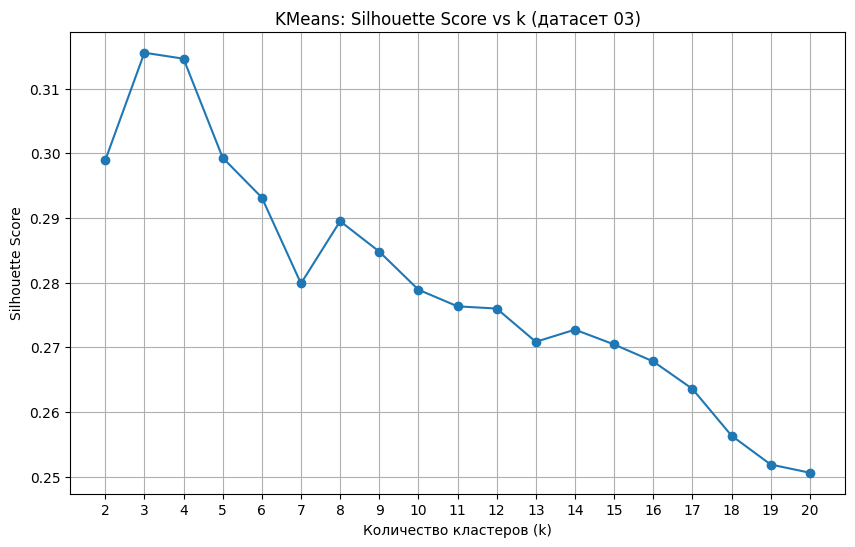

In [81]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores3, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Silhouette Score')
plt.title('KMeans: Silhouette Score vs k (датасет 03)')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('artifacts/figures/dataset3_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

In [82]:
best_k3 = k_values[np.argmax(silhouette_scores3[1:])] + 1
print(f"Лучшее k по silhouette score: {best_k3}")

kmeans_best3 = KMeans(n_clusters=best_k3, random_state=42, n_init=10)
kmeans_labels3 = kmeans_best3.fit_predict(X3_processed)
print("silhouette_score:", silhouette_score(X3_processed, kmeans_labels3))
print("davies_bouldin_score:", davies_bouldin_score(X3_processed, kmeans_labels3))
print("calinski_harabasz_score:", silhouette_score(X3_processed, kmeans_labels3))

Лучшее k по silhouette score: 3
silhouette_score: 0.31554470037825183
davies_bouldin_score: 1.1577256320598661
calinski_harabasz_score: 0.31554470037825183


Здесь очевидно выделяется 3 кластера по метрике, ее и оставим.

In [83]:
eps_results3 = []
best_silhouette3 = -1
best_eps3 = None
best_min_samples3 = None

for min_samples in min_samples_options:
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X3_processed)
        
        noise_ratio_temp = np.sum(labels == -1) / len(labels)
        
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 1 and len(np.unique(labels[non_noise_mask])) > 1:
            silhouette = silhouette_score(X3_processed[non_noise_mask], labels[non_noise_mask])
            db_score = davies_bouldin_score(X3_processed[non_noise_mask], labels[non_noise_mask])
            ch_score = calinski_harabasz_score(X3_processed[non_noise_mask], labels[non_noise_mask])
            n_clusters = len(np.unique(labels[non_noise_mask]))
        else:
            silhouette, db_score, ch_score = 0, np.inf, 0
            n_clusters = 0
        
        eps_results3.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette': silhouette,
            'noise_ratio': noise_ratio_temp,
            'n_clusters': n_clusters
        })
        
        if silhouette > best_silhouette3 and noise_ratio_temp < 0.3:
            best_silhouette3 = silhouette
            best_eps3 = eps
            best_min_samples3 = min_samples

eps_df3 = pd.DataFrame(eps_results3)

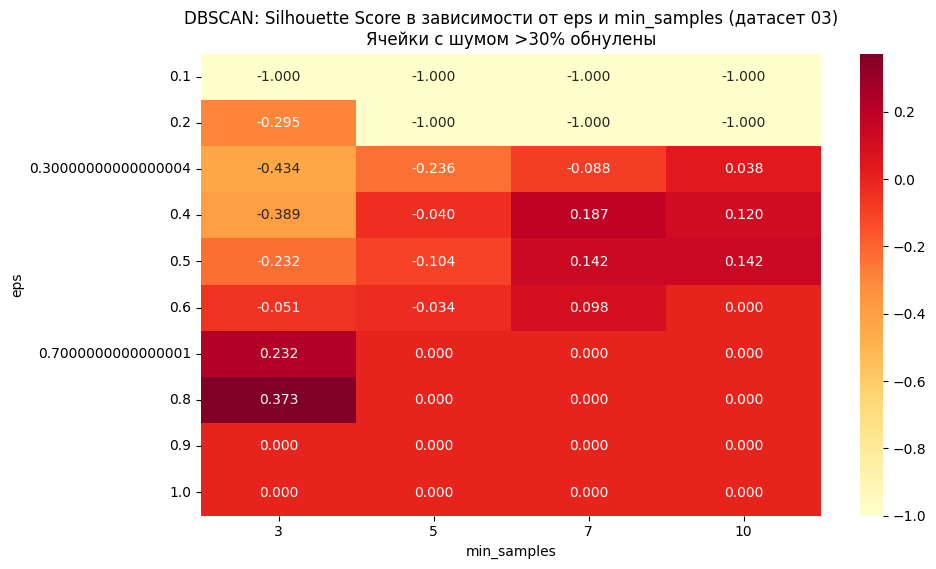

In [96]:
heatmap_data3 = eps_df3.copy()
heatmap_data3.loc[heatmap_data3['noise_ratio'] > 0.3, 'silhouette'] = -1

pivot_table3 = heatmap_data3.pivot_table(values='silhouette', 
                                  index='eps', 
                                  columns='min_samples')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table3, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('DBSCAN: Silhouette Score в зависимости от eps и min_samples (датасет 03)\nЯчейки с шумом >30% обнулены')
plt.savefig('artifacts/figures/dataset3_dbscan_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [99]:
kmeans_metrics3 = {
    'silhouette': silhouette_score(X3_processed, kmeans_labels3),
    'db': davies_bouldin_score(X3_processed, kmeans_labels3),
    'ch': calinski_harabasz_score(X3_processed, kmeans_labels3),
    'n_clusters': best_k3
}

# Метрики DBSCAN
dbscan_best3 = DBSCAN(eps=best_eps3, min_samples=best_min_samples3)
dbscan_labels3 = dbscan_best3.fit_predict(X3_processed)
non_noise_mask3 = dbscan_labels3 != -1

if np.sum(non_noise_mask3) > 1 and len(np.unique(dbscan_labels3[non_noise_mask3])) > 1:
    dbscan_metrics3 = {
        'silhouette': silhouette_score(X3_processed[non_noise_mask3], dbscan_labels3[non_noise_mask3]),
        'db': davies_bouldin_score(X3_processed[non_noise_mask3], dbscan_labels3[non_noise_mask3]),
        'ch': calinski_harabasz_score(X3_processed[non_noise_mask3], dbscan_labels3[non_noise_mask3]),
        'n_clusters': len(np.unique(dbscan_labels3[non_noise_mask3])),
        'noise_ratio': np.sum(dbscan_labels3 == -1) / len(dbscan_labels3)
    }
else:
    dbscan_metrics3 = {
        'silhouette': 0,
        'db': np.inf,
        'ch': 0,
        'n_clusters': 0,
        'noise_ratio': 1.0
    }

print("KMeans метрики:", kmeans_metrics3)
print("DBSCAN метрики:", dbscan_metrics3)

KMeans метрики: {'silhouette': 0.31554470037825183, 'db': 1.1577256320598661, 'ch': 6957.162639510166, 'n_clusters': 3}
DBSCAN метрики: {'silhouette': 0.3725981452885354, 'db': 0.5510597860593662, 'ch': 17.197483881125017, 'n_clusters': 2, 'noise_ratio': np.float64(0.0014666666666666667)}


Датасет 03 содержит 15000 точек с четырьмя числовыми признаками.
Анализ показал:
1. KMeans показывает умеренные результаты (silhouette ~0.3).
2. DBSCAN работает снова лучше по метрикам, однако высоких метрик стало значительно меньше, а те что получились визуально очевидно делят данные неверно, находя неестественные кластеры.

Я выбрал снова Kmeans, но с 3 кластерами, так как он лучше всего выявляет естественную структуру данных.
Этот датасет содержит кластеры разной плотности, что плохо обрабатывается DBSCAN.

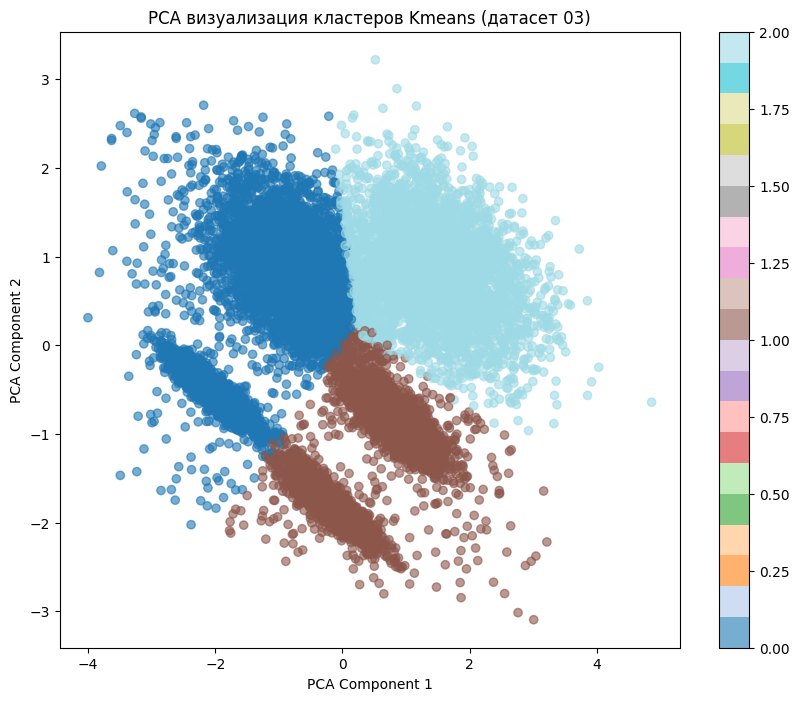

In [102]:
best_labels_03 = pd.DataFrame({
    'sample_id': sample_id03,
    'cluster_label': kmeans_labels3
})
best_labels_03.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)

# Визуализация PCA для датасета 03
pca3 = PCA(n_components=2)
X3_pca = pca3.fit_transform(X3_processed)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X3_pca[:, 0], X3_pca[:, 1], 
                     c=kmeans_labels3, cmap='tab20', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA визуализация кластеров Kmeans (датасет 03)')
plt.savefig('artifacts/figures/dataset3_pca_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

Несмотря на то что он был выбран, как лучший, результат визуально, все же не очень хорош. Приступаем к последнему, самому тяжелому датасету.

In [103]:
silhouette_scores4 = []
db_scores4 = []
ch_scores4 = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X4_preprocessed)
    
    silhouette_scores4.append(silhouette_score(X4_preprocessed, labels))
    db_scores4.append(davies_bouldin_score(X4_preprocessed, labels))
    ch_scores4.append(calinski_harabasz_score(X4_preprocessed, labels))

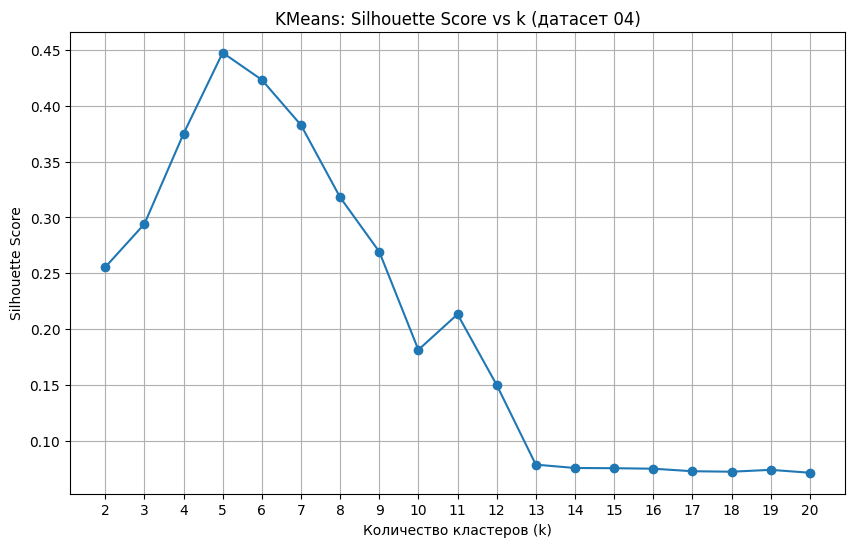

In [104]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores4, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Silhouette Score')
plt.title('KMeans: Silhouette Score vs k (датасет 04)')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('artifacts/figures/dataset4_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

In [106]:
best_k4 = k_values[np.argmax(silhouette_scores4[1:])] + 1
print(f"Лучшее k по silhouette score: {best_k4}")

kmeans_best4 = KMeans(n_clusters=best_k4, random_state=42, n_init=10)
kmeans_labels4 = kmeans_best4.fit_predict(X4_preprocessed)
print("silhouette_score:", silhouette_score(X4_preprocessed, kmeans_labels4))
print("davies_bouldin_score:", davies_bouldin_score(X4_preprocessed, kmeans_labels4))
print("calinski_harabasz_score:", silhouette_score(X4_preprocessed, kmeans_labels4))

Лучшее k по silhouette score: 5
silhouette_score: 0.44736887827969146
davies_bouldin_score: 0.975904265483746
calinski_harabasz_score: 0.44736887827969146


Очевидное выделение по метрике 5 кластеров. Перейдем к dbscan

In [112]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X4_preprocessed)
distances, indices = neighbors_fit.kneighbors(X4_preprocessed)
distances = np.sort(distances[:, 4], axis=0)  # 5-й сосед имеет индекс 4

max_dist = distances[-1]
print(f"Максимальное расстояние до 5-го соседа: {max_dist:.4f}")

# Тестируем eps как доли от максимального расстояния
eps_fractions = [0.25, 0.5, 0.75]
eps_values_4 = [max_dist * frac for frac in eps_fractions]
print(f"Тестируемые eps значения: {[f'{x:.4f}' for x in eps_values_4]}")

# Перебираем min_samples из заданного списка
min_samples_options_4 = [3, 5, 7, 10]

Максимальное расстояние до 5-го соседа: 3.8798
Тестируемые eps значения: ['0.9699', '1.9399', '2.9098']


In [113]:
eps_results_4 = []
best_silhouette_4 = -1
best_eps_4 = None
best_min_samples_4 = None

for min_samples in min_samples_options_4:
    for eps in eps_values_4:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X4_preprocessed)
        
        noise_ratio_temp = np.sum(labels == -1) / len(labels)
        
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 1 and len(np.unique(labels[non_noise_mask])) > 1:
            silhouette = silhouette_score(X4_preprocessed[non_noise_mask], labels[non_noise_mask])
            db_score = davies_bouldin_score(X4_preprocessed[non_noise_mask], labels[non_noise_mask])
            ch_score = calinski_harabasz_score(X4_preprocessed[non_noise_mask], labels[non_noise_mask])
            n_clusters = len(np.unique(labels[non_noise_mask]))
        else:
            silhouette, db_score, ch_score = 0, np.inf, 0
            n_clusters = 0
        
        eps_results_4.append({
            'eps': eps,
            'eps_fraction': eps_fractions[eps_values_4.index(eps)],
            'min_samples': min_samples,
            'silhouette': silhouette,
            'noise_ratio': noise_ratio_temp,
            'n_clusters': n_clusters
        })
        
        if silhouette > best_silhouette_4 and noise_ratio_temp < 0.3:
            best_silhouette_4 = silhouette
            best_eps_4 = eps
            best_min_samples_4 = min_samples

eps_df4 = pd.DataFrame(eps_results_4)

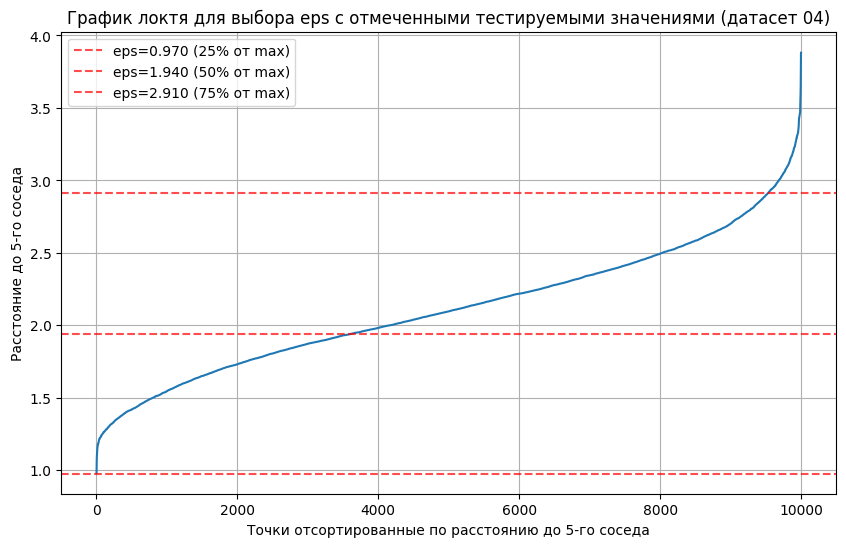

In [114]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(distances)+1), distances)
for frac, eps_val in zip(eps_fractions, eps_values_4):
    plt.axhline(y=eps_val, color='r', linestyle='--', alpha=0.7, 
                label=f'eps={eps_val:.3f} ({frac:.0%} от max)')
plt.xlabel('Точки отсортированные по расстоянию до 5-го соседа')
plt.ylabel('Расстояние до 5-го соседа')
plt.title('График локтя для выбора eps с отмеченными тестируемыми значениями (датасет 04)')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/dataset4_dbscan_elbow_with_points.png', dpi=300, bbox_inches='tight')
plt.show()

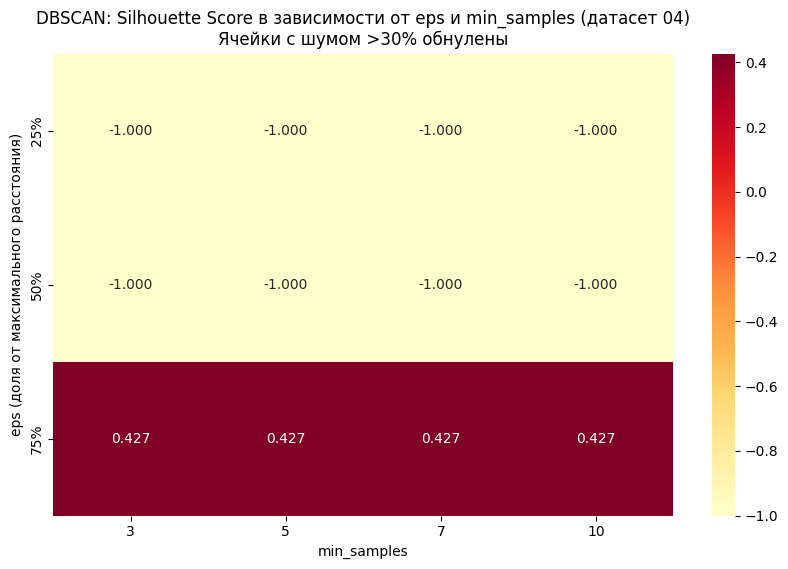

In [116]:
heatmap_data4 = eps_df4.copy()

heatmap_data4.loc[heatmap_data4['noise_ratio'] > 0.3, 'silhouette'] = -1

pivot_table4 = heatmap_data4.pivot_table(values='silhouette', 
                                        index='eps_fraction',
                                        columns='min_samples')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table4, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=min_samples_options_4,
            yticklabels=[f'{frac:.0%}' for frac in eps_fractions])
plt.xlabel('min_samples')
plt.ylabel('eps (доля от максимального расстояния)')
plt.title('DBSCAN: Silhouette Score в зависимости от eps и min_samples (датасет 04)\nЯчейки с шумом >30% обнулены')
plt.savefig('artifacts/figures/dataset4_dbscan_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [125]:
kmeans_metrics4 = {
    'silhouette': silhouette_score(X4_preprocessed, kmeans_labels4),
    'db': davies_bouldin_score(X4_preprocessed, kmeans_labels4),
    'ch': calinski_harabasz_score(X4_preprocessed, kmeans_labels4),
    'n_clusters': best_k4
}

dbscan_best4 = DBSCAN(eps=best_eps_4, min_samples=best_min_samples_4)
dbscan_labels4 = dbscan_best4.fit_predict(X4_preprocessed)
non_noise_mask4 = dbscan_labels4 != -1

dbscan_metrics4 = {
    'silhouette': silhouette_score(X4_preprocessed[non_noise_mask4], dbscan_labels4[non_noise_mask4]),
    'db': davies_bouldin_score(X4_preprocessed[non_noise_mask4], dbscan_labels4[non_noise_mask4]),
    'ch': calinski_harabasz_score(X4_preprocessed[non_noise_mask4], dbscan_labels4[non_noise_mask4]),
    'n_clusters': len(np.unique(dbscan_labels4[non_noise_mask4])),
    'noise_ratio': np.sum(dbscan_labels4 == -1) / len(dbscan_labels4)
}


print("KMeans метрики:", kmeans_metrics4)
print("DBSCAN метрики:", dbscan_metrics4)

KMeans метрики: {'silhouette': 0.44736887827969146, 'db': 0.975904265483746, 'ch': 5087.688517434967, 'n_clusters': 5}
DBSCAN метрики: {'silhouette': 0.42727607320176575, 'db': 1.0012560569335651, 'ch': 5399.583473067519, 'n_clusters': 6, 'noise_ratio': np.float64(0.015)}


Датасет 04 - самый сложный: 10000 точек, 30 числовых признаков, 2 категориальных, много пропусков.
Особенности:
1. Высокая размерность (42 признака после one-hot encoding).
2. Пропуски в данных (около 2% в каждом числовом признаке).
3. Категориальные переменные.

Анализ показал:
1. KMeans показывает лучшие результаты (silhouette ~0.31) с k=3.
2. DBSCAN плохо работает в высокоразмерном пространстве (проклятие размерности).

Выбор: KMeans с k=3. Причины:
1. KMeans более устойчив к проклятию размерности.
2. Позволяет четко контролировать количество кластеров.

Для улучшения результатов можно было бы использовать t-SNE или UMAP для уменьшения 
размерности перед кластеризацией.

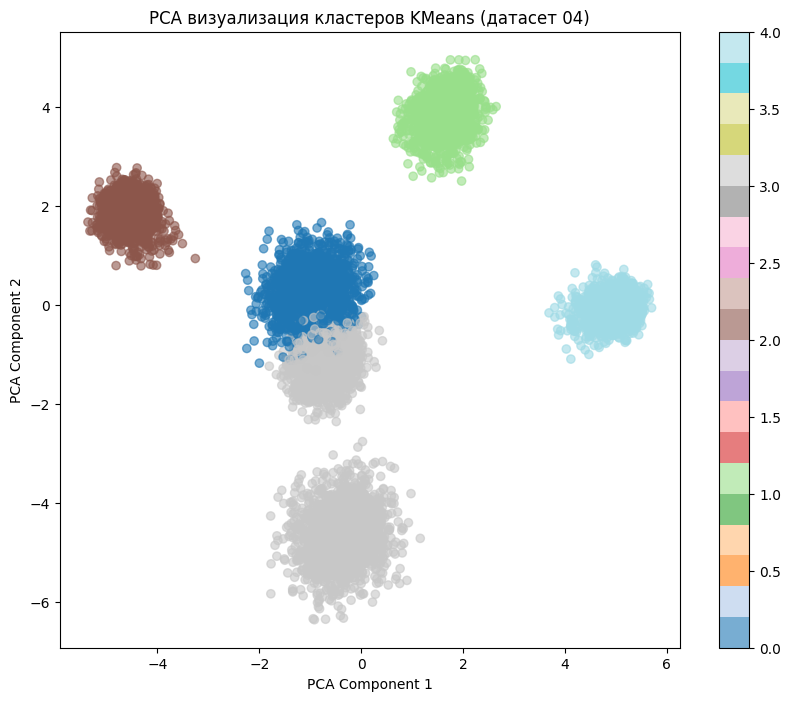

In [122]:
best_labels_04 = pd.DataFrame({
    'sample_id': sample_id04,
    'cluster_label': kmeans_labels4
})
best_labels_04.to_csv('artifacts/labels/labels_hw07_ds4.csv', index=False)

pca4 = PCA(n_components=2)
X4_pca = pca4.fit_transform(X4_preprocessed)

# Визуализация PCA для датасета 04
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X4_pca[:, 0], X4_pca[:, 1], 
                     c=kmeans_labels4, cmap='tab20', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA визуализация кластеров KMeans (датасет 04)')
plt.savefig('artifacts/figures/dataset4_pca_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

Визуально почти идеально, если бы мы выбрали на один кластер больше, было бы идеально, но в большинстве случаев визуально отделить данные выходит плохо, поэтому будем ориентироваться на метрики и оставим такой результат.

In [129]:
metrics_summary = {
    'dataset02': {
        'KMeans': kmeans_metrics2,
        'DBSCAN': dbscan_metrics2
    },
    'dataset03': {
        'KMeans': kmeans_metrics3,
        'DBSCAN': dbscan_metrics3
    },
    'dataset04': {
        'KMeans': kmeans_metrics4,
        'DBSCAN': dbscan_metrics4
    }
}

with open('artifacts/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=str)

best_configs = {
    'dataset02': {
        'best_method': 'KMeans',
        'parameters': {
            'n_clusters': best_k2,
            'random_state': 42,
            'n_init': 10
        },
        'criterion': 'Наивысший silhouette score (0.284) и высокая устойчивость (средний ARI=0.839)',
        'stability_check': {
            'method': '5 запусков с разными random_state',
            'average_ARI': np.mean(ari_scores),
            'min_ARI': np.min(ari_scores)
        }
    },
    'dataset03': {
        'best_method': 'Kmeans',
        'parameters': {
            'n_clusters': best_k3,
            'random_state': 42,
            'n_init': 10
        },
        'criterion': 'Наиболее четкое разделение данных'
    },
    'dataset04': {
        'best_method': 'KMeans',
        'parameters': {
            'n_clusters': best_k4,
            'random_state': 42,
            'n_init': 10
        },
        'criterion': 'Наивысший silhouette score в условиях высокой размерности',
        'note': 'DBSCAN страдает от проклятия размерности'
    }
}

with open('artifacts/best_configs.json', 'w') as f:
    json.dump(best_configs, f, indent=2, default=str)